<a href="https://colab.research.google.com/github/Joaomaxado/Joaomaxado/blob/main/Projeto_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

                                             title       Marca  Preco_Normal  \
0             Pack 12 un, Leche extra proteína 1 L  Loncoleche         19788   
1  Pack 12 un, Leche chocolate receta original 1 L     Soprole         18228   
2   Pack 12 un, Leche semidescremada chocolate 1 L     Soprole         18228   
3    Pack 12 un, Leche semidescremada frutilla 1 L     Soprole         18228   
4      Pack 12 un, Leche sin lactosa chocolate 1 L  Loncoleche         17988   

   Preco_Desconto  Preco_Anterior  Desconto Categoria  
0               0               0         0   lacteos  
1               0               0         0   lacteos  
2               0               0         0   lacteos  
3               0               0         0   lacteos  
4               0               0         0   lacteos  


/tmp/ipykernel_1079/177780852.py:25: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



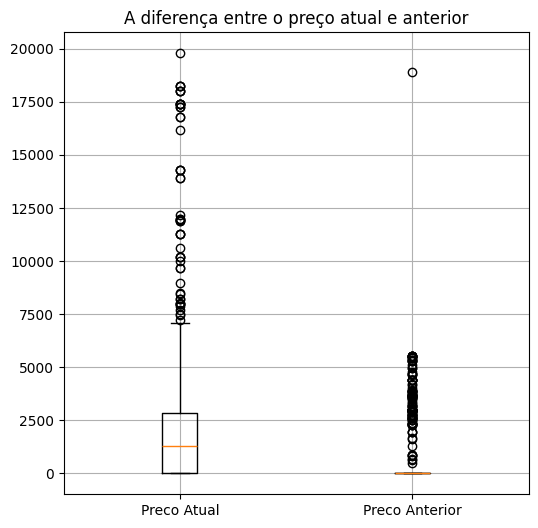

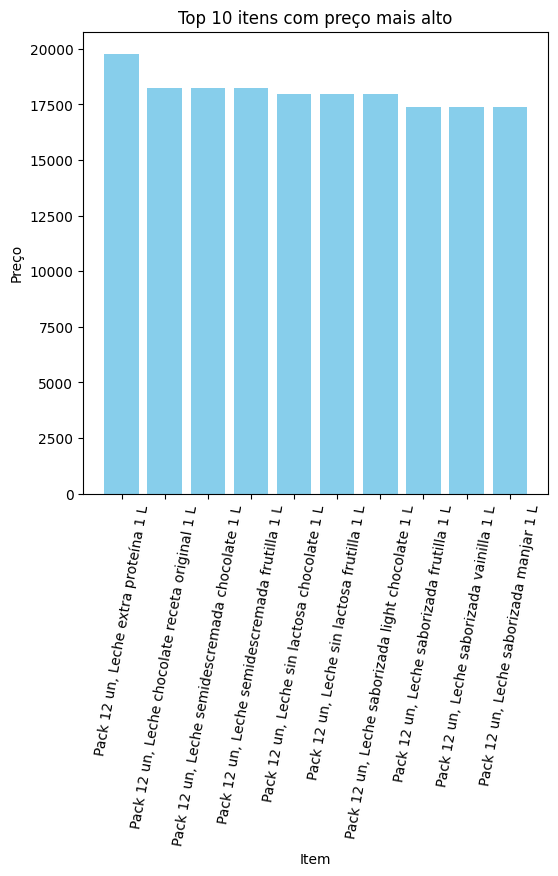

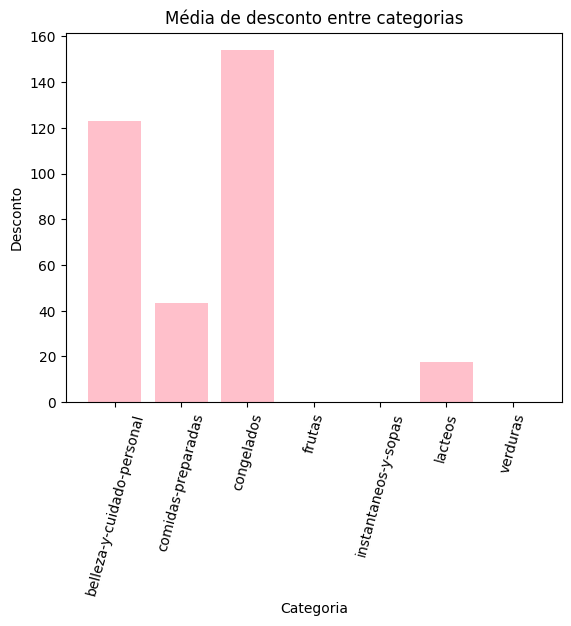

In [64]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt

# Objetivo do projeto é fazer cálculos estatísticos sobre o arquivo e criar visualização interativa e publicar no github
df = pd.read_csv('MODULO7_PROJETOFINAL_BASE_SUPERMERCADO.csv')
pd.set_option('display.max_columns', None)

df['Preco_Normal'] = pd.to_numeric(df['Preco_Normal'], errors='coerce') # ''errors='coerce'' é para quando haver valores que não foram convertidos para númerico, que sejam convertidos em NaN

df.dropna(subset=['Preco_Normal'], inplace=True) # O subset é colocado para excluir valores nulos apenas na coluna 'Preco Normal'.

itens_mais_caros = df.groupby('title')['Preco_Normal'].mean().reset_index()
ticket_medio = df['Preco_Normal'].mean()

fig = px.bar(itens_mais_caros, x='Preco_Normal', y='title', orientation='h',
            title= 'Dispersão de valores entre itens',
            labels={'title':'Item', 'Preco_Normal':'Preço'},
            color_discrete_sequence=['red'])
fig.show()

# Diferença de preço entre o atual e o anterior
plt.figure(figsize=(6,6))
plt.boxplot([df['Preco_Normal'], df['Preco_Anterior']], labels=['Preco Atual', 'Preco Anterior'])
plt.title('A diferença entre o preço atual e anterior')
plt.grid(True, linestyle='-')
plt.show()


# Identificação de outliers
Q1 = df['Preco_Normal'].quantile(0.25)
Q3 = df['Preco_Normal'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['Preco_Normal'] < Q1 - 1.5*IQR) |
       (df['Preco_Normal'] > Q3 + 1.5*IQR)]

top_outliers = outliers.sort_values(by='Preco_Normal', ascending=False).head(10)

plt.figure(figsize=(6,6))
plt.bar(top_outliers['title'], top_outliers['Preco_Normal'], color='skyblue')
plt.title('Top 10 itens com preço mais alto')
plt.xlabel('Item')
plt.ylabel('Preço')
plt.xticks(rotation=80)
plt.show()

# A média de desconto entre categoria
media = df.groupby('Categoria')['Desconto'].mean()
plt.bar(media.index, media.values, color='pink')
plt.title('Média de desconto entre categorias')
plt.xlabel('Categoria')
plt.ylabel('Desconto')
plt.xticks(rotation=75)
plt.show()